
# Load Forecasting Notebook

This notebook performs load forecasting using XGBoost on the AEP PJM dataset.


#1 Import the libraries!

In [107]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import warnings
warnings.filterwarnings("ignore")


#2 pull in the csv data to the panda data frame and sort them by date time. check the top rows!


In [108]:

df = pd.read_csv("AEP_hourly.csv", parse_dates=["Datetime"])
#df.columns = ["Datetime", "MW"]
df = df.sort_values("Datetime")
df.set_index("Datetime", inplace=True)
df.head()


,MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


#3 fill in the missing values in the MW column by the estimated values from the time index then check if still any  mw value is missing..

In [109]:

df["MW"] = df["MW"].interpolate(method="time")
df.isna().sum()


MW    0
dtype: int64

#4 make the figure of AEP load from last year ( which is 2017 2018 in this case)

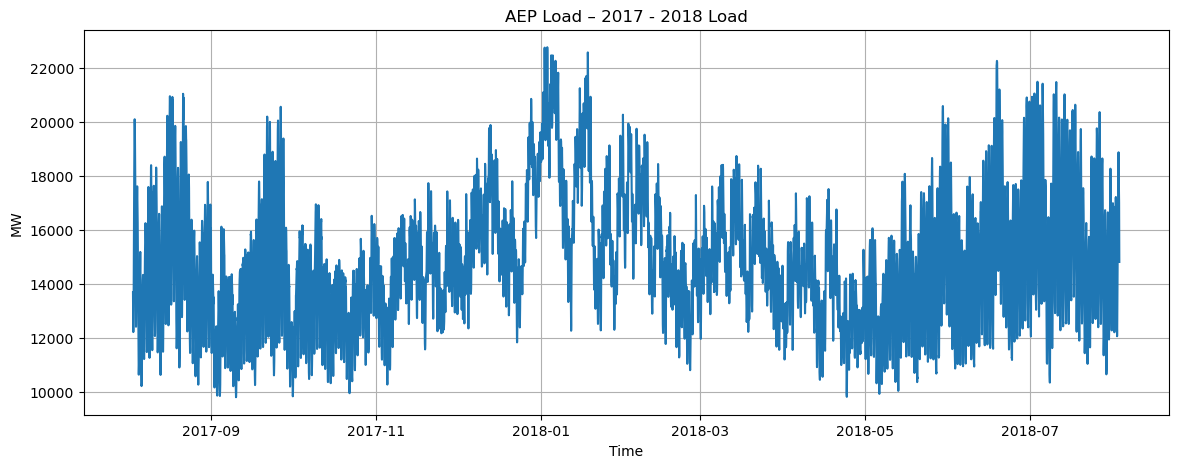

In [110]:

plt.figure(figsize=(14, 5))
plt.plot(df["MW"].iloc[-365*24:])
plt.title("AEP Load – 2017 - 2018 Load")
plt.xlabel("Time")
plt.ylabel("MW")
plt.grid(True)
plt.show()


### Feature Engineering

#5 Visulize how the load changes by hour of the day by extracting the hour and day of week from each time stamp and assingning them as new columns.

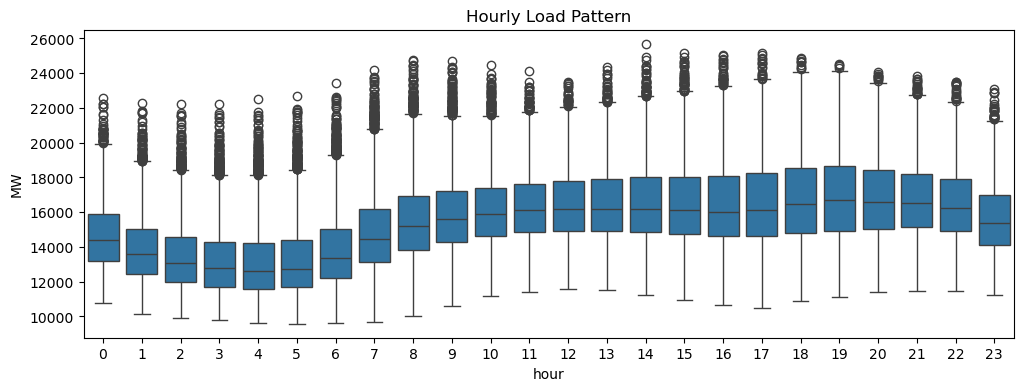

In [111]:

df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek

plt.figure(figsize=(12, 4))
sns.boxplot(x=df["hour"], y=df["MW"])
plt.title("Hourly Load Pattern")
plt.show()


### Visualizing Weekend vs Weekday Load Patterns

the differnece of weekends and weekdays load patterns


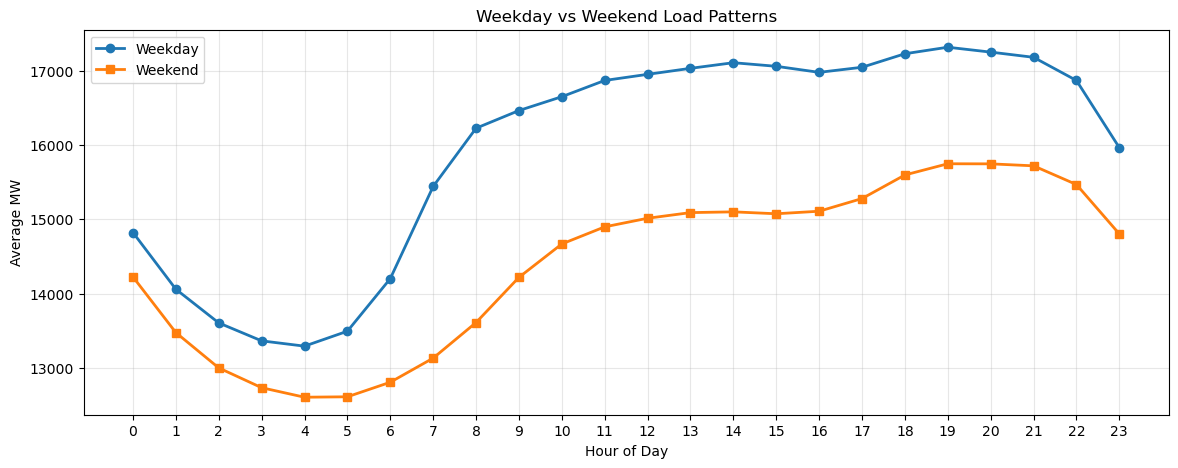

Average weekday load: 15936.69 MW
Average weekend load: 14405.99 MW
Difference: 1530.70 MW


In [112]:
# Add is_weekend column temporarily for visualization
df_temp = df.copy()
df_temp["is_weekend"] = (df_temp.index.dayofweek >= 5).astype(int)

# Compare average load by hour for weekdays vs weekends
weekday_hourly = df_temp[df_temp["is_weekend"] == 0].groupby("hour")["MW"].mean()
weekend_hourly = df_temp[df_temp["is_weekend"] == 1].groupby("hour")["MW"].mean()

plt.figure(figsize=(14, 5))
plt.plot(weekday_hourly.index, weekday_hourly.values, label="Weekday", linewidth=2, marker='o')
plt.plot(weekend_hourly.index, weekend_hourly.values, label="Weekend", linewidth=2, marker='s')
plt.xlabel("Hour of Day")
plt.ylabel("Average MW")
plt.title("Weekday vs Weekend Load Patterns")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.show()

print(f"Average weekday load: {df_temp[df_temp['is_weekend']==0]['MW'].mean():.2f} MW")
print(f"Average weekend load: {df_temp[df_temp['is_weekend']==1]['MW'].mean():.2f} MW")
print(f"Difference: {df_temp[df_temp['is_weekend']==0]['MW'].mean() - df_temp[df_temp['is_weekend']==1]['MW'].mean():.2f} MW")

#6 Feature Engineering: Create time-based and lagged features
Time series data has memory and future values depend on past values. 

Without lags, the model only knows "it's 3 PM on Monday" but not "the load was 15,000 MW an hour ago." Lagged features give the model this temporal context,that improves forecast accuracy.

Temporal Features:
- `month`: Extracts the month (1-12) to capture seasonal patterns (e.g., higher AC load in summer)
- `is_weekend`: Binary flag (1 for Sat/Sun, 0 otherwise) since weekends have different load patterns than weekdays

Lagged Features:
Lagged features are past values of the target variable (MW) that help the model understand temporal dependencies:
- `lag_1`: Load from 1 hour ago which provides immediate short-term trend
- `lag_24`: Load from 24 hours ago (same time yesterday) which captures daily patterns
- `lag_168`: Load from 168 hours ago (same time last week) which captures weekly patterns

Rolling Average Features:
These smooth out short-term fluctuations and reveal underlying trends:
- `rolling_24h_mean`: Average load over the past 24 hours
- `rolling_168h_mean`: Average load over the past week

`dropna()` removes rows where lag/rolling calculations produced NaN values (the first 168 rows).

In [113]:

df["month"] = df.index.month
df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

df["lag_1"] = df["MW"].shift(1)
df["lag_24"] = df["MW"].shift(24)
df["lag_168"] = df["MW"].shift(168)

df["rolling_24h_mean"] = df["MW"].rolling(24).mean()
df["rolling_168h_mean"] = df["MW"].rolling(168).mean()

df = df.dropna()


In [114]:

features = [
    "hour", "dayofweek", "month", "is_weekend",
    "lag_1", "lag_24", "lag_168",
    "rolling_24h_mean", "rolling_168h_mean"
]


7# Train/Test split

train = df.loc[:"2017-12-31"]: All data up to and including Dec 31, 2017 → training set

test = df.loc["2018-01-01":]: All data from Jan 1, 2018 onward → test set

In [115]:

train = df.loc[:"2017-12-31"]
test  = df.loc["2018-01-01":]

X_train = train[features]
y_train = train["MW"]

X_test = test[features]
y_test = test["MW"]


#8 Hyperparameter Tuning with Grid Search

TimeSeriesSplit is used for cross-validation (respects temporal order) and GridSearchCV to find optimal XGBoost parameters.

In [116]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 9],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Create base model
base_model = XGBRegressor(random_state=42)

# Setup TimeSeriesSplit for cross-validation (respects temporal order)
tscv = TimeSeriesSplit(n_splits=3)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV RMSE: {np.sqrt(-grid_search.best_score_):.2f} MW")

# Use best model
model = grid_search.best_estimator_

Starting Grid Search...
Fitting 3 folds for each of 243 candidates, totalling 729 fits

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best CV RMSE: 184.99 MW

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best CV RMSE: 184.99 MW


In [117]:

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse


np.float64(176.9521386231495)

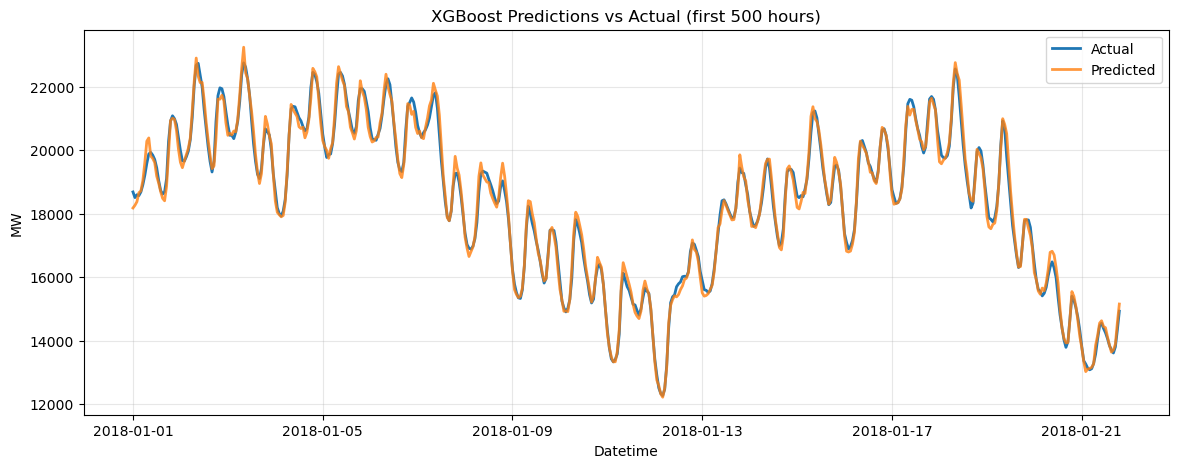

In [118]:

plt.figure(figsize=(14,5))
plt.plot(y_test.index[:500], y_test.iloc[:500], label="Actual", linewidth=2)
plt.plot(y_test.index[:500], y_pred[:500], label="Predicted", linewidth=2, alpha=0.8)
plt.legend()
plt.title("XGBoost Predictions vs Actual (first 500 hours)")
plt.xlabel("Datetime")
plt.ylabel("MW")
plt.grid(True, alpha=0.3)
plt.show()


<Figure size 1000x600 with 0 Axes>

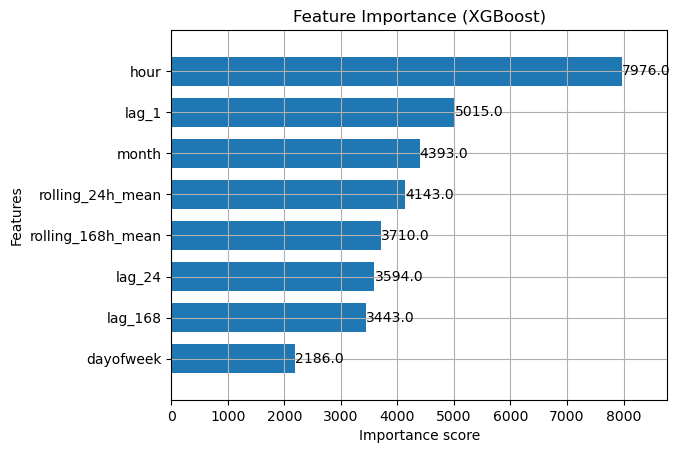

In [119]:

plt.figure(figsize=(10,6))
plot_importance(model, height=0.7)
plt.title("Feature Importance (XGBoost)")
plt.show()


In [120]:

def forecast_n_hours(model, df, n_steps):
    df_copy = df.copy()
    last_row = df_copy.iloc[-1].copy()
    future_preds, future_times = [], []

    for _ in range(n_steps):
        next_time = last_row.name + pd.Timedelta(hours=1)

        row = {
            "hour": next_time.hour,
            "dayofweek": next_time.dayofweek,
            "month": next_time.month,
            "is_weekend": int(next_time.dayofweek >= 5),
            "lag_1": last_row["MW"],
            "lag_24": df_copy.loc[next_time - pd.Timedelta(hours=24), "MW"]
                      if (next_time - pd.Timedelta(hours=24)) in df_copy.index
                      else last_row["MW"],
            "lag_168": df_copy.loc[next_time - pd.Timedelta(hours=168), "MW"]
                      if (next_time - pd.Timedelta(hours=168)) in df_copy.index
                      else last_row["MW"],
            "rolling_24h_mean": df_copy["MW"].iloc[-24:].mean(),
            "rolling_168h_mean": df_copy["MW"].iloc[-168:].mean(),
        }

        next_pred = model.predict(pd.DataFrame([row]))[0]

        future_preds.append(next_pred)
        future_times.append(next_time)

        last_row["MW"] = next_pred
        last_row.name = next_time
        df_copy.loc[next_time] = last_row

    return pd.DataFrame({"Datetime": future_times, "Predicted_MW": future_preds})


In [121]:

forecast_df = forecast_n_hours(model, df.copy(), 24)
forecast_df.head()


,Datetime,Predicted_MW
0,2018-08-03 01:00:00,13713.220703
1,2018-08-03 02:00:00,13015.039062
2,2018-08-03 03:00:00,12601.033203
3,2018-08-03 04:00:00,12330.832031
4,2018-08-03 05:00:00,12347.040039


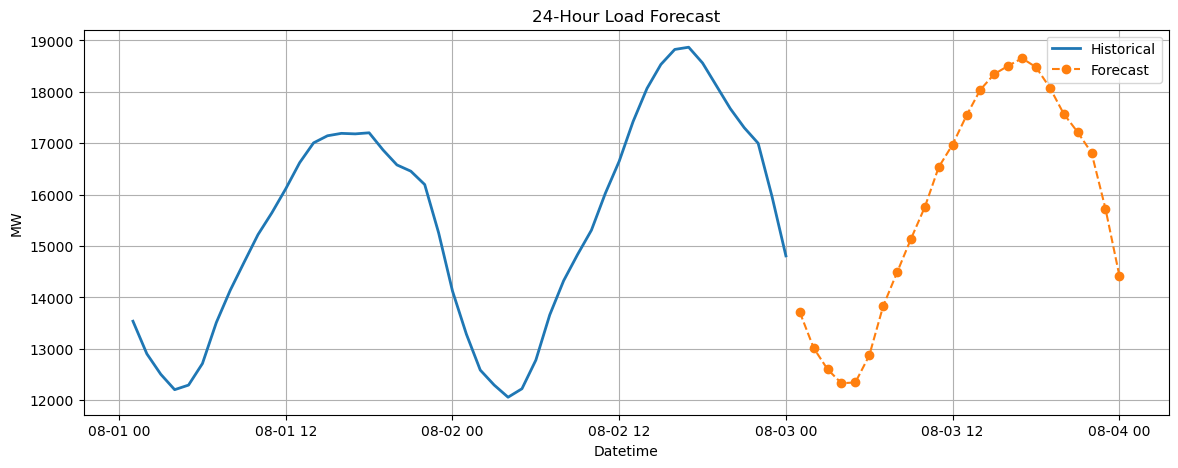

In [122]:

plt.figure(figsize=(14,5))
plt.plot(df["MW"].iloc[-48:], label="Historical", linewidth=2)
plt.plot(forecast_df["Datetime"], forecast_df["Predicted_MW"],
         label="Forecast", linestyle="--", marker="o")
plt.legend()
plt.grid(True)
plt.title("24-Hour Load Forecast")
plt.xlabel("Datetime")
plt.ylabel("MW")
plt.show()
